<table>
<tr>
<td><img src="https://raw.githubusercontent.com/RafaelCaballero/APD/refs/heads/main/img/logoAPD.png" width="150"></td>
<td><table><tr><td><h1>Outliers</h1></td></tr>
           <tr><td><h3>Rafael Caballero Roldán</h3></td></tr></table></td>
<td><img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTsPjCdm67xYS9AM7-dXQ46O23vaexAhnVJaQ&s" width="105"></td>
</tr>
</table>



# Tabla de Contenidos
1 [Introducción](#5.1-Introducción)<br>
2 [Histogramas](#5.2-Histogramas)<br>
3 [Boxplots](#5.3-Boxplots)<br>
4 [Métodos numéricos](#5.4-Métodos-numéricos)<br>
5 [Outliers en varias dimensiones](#5.5-Outliers-en-varias-dimensiones)<br>
  
6. [Referencias](#6.-Referencias)<br>


Ejecutar el código siguiente para asegurarse de que están todas las librerías instaladas. Si se instala alguna nueva suele ser buena idea dar a Kernel+Restart Kernel y volver a ejecutar esta casilla (algunos módulos puede poner que siguen sin estar instalados, pero no precuparse de este alarmante mensaje, sí lo están)

In [1]:
modules = ["matplotlib","pandas","numpy", "PyQt6","plotly","seaborn","ipywidgets"]

import sys
import os.path
from subprocess import check_call
import importlib
import os

def instala(modules):
    print("Instalando módulos")
    for m in modules:
        # para el import quitamos [...] y ==...
        p = m.find("[")
        mi = m if p==-1 else m[:p]
        p = mi.find("==")
        mi = mi if p==-1 else mi[:p]
        torch_loader = importlib.util.find_spec(mi)
        if torch_loader is not None:
            print(m," encontrado")
        else:
            print(m," No encontrado, instalando...",end="")  
            try:        
                r = check_call([sys.executable, "-m", "pip", "install", "--user", m])
                print("¡hecho!")
            except:
                print("¡Problema al instalar ",m,"! ¿seguro que el módulo existe?",sep="")

    print("¡Terminado!")

instala(modules) 

Instalando módulos
matplotlib  encontrado
pandas  encontrado
numpy  encontrado
PyQt6  encontrado
plotly  encontrado
seaborn  encontrado
ipywidgets  encontrado
¡Terminado!




### 1 Introducción

¿Qué es un outlier? Una posible definición sería 

*un valor que se desvía tanto del resto que lleva a sospechar que se ha producido a través de un mecanismo diferente* 

Ese mecanismo diferente puede ser un error en la toma de datos o una circunstancia especial. 

Al considerar outliers no debemos utilizar la media y la desviación típica, porque son valores que se ven muy afectados por los propios outliers. En su lugar utilizaremos medidas más *robustas* como la mediana. Hay multitud de métodos dado que se trata de un problema recurrente y fundamental. Aquí vamos a ver dos tipos de métodos:

* Visuales (boxplots)
* Estadísticos

Para más detalles ver las [referencias](#6.-Referencias)


## Ejemplo

Como ejemplo vamos a ver las estadísticas de varios pilotos de Fórmula 1 en el gran premio de Singapur en 2024. 

Estos datos nos los proporciona la siguiente librería (código comentado)


In [116]:
#!pip install --user --upgrade fastf1

In [117]:
"""
import fastf1
from fastf1 import plotting
from matplotlib import pyplot as plt

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

fastf1.Cache.enable_cache('.')

race = fastf1.get_session(2024, 'Singapur', 'R')
race.load()

short = ["NOR","VER","ALO","RUS"]
delta_cols = ["LapTime","Sector1Time","Sector2Time","Sector3Time"]
drivers = []
for s in short:
    df = race.laps.pick_driver(s)
    df.loc[:,"Driver"] = s
    df = df.drop(columns=["DriverNumber", "Time","PitOutTime", "Sector1SessionTime","Sector2SessionTime",
                          "Sector3SessionTime","SpeedI1","SpeedI2","SpeedFL",
                        "IsPersonalBest","LapStartTime","FreshTyre","Stint","LapStartDate","TrackStatus","IsAccurate"])
    df["PitInTime"] = pd.to_timedelta(df["PitInTime"])
    df.loc[df["PitInTime"].isna(),"PitInTime"] = 0
    # convertimos las columnas tipo time delta a segundos
    for c in delta_cols:
        df[c] = df[c].dt.total_seconds()
    drivers.append(df)

f1 = pd.concat(drivers,axis=0)
f1.to_csv("f1-Singapur24.csv", index=False)
"""

'\nimport fastf1\nfrom fastf1 import plotting\nfrom matplotlib import pyplot as plt\n\nimport pandas as pd\nimport warnings\nwarnings.filterwarnings(\'ignore\')\n\nfastf1.Cache.enable_cache(\'.\')\n\nrace = fastf1.get_session(2024, \'Singapur\', \'R\')\nrace.load()\n\nshort = ["NOR","VER","ALO","RUS"]\ndelta_cols = ["LapTime","Sector1Time","Sector2Time","Sector3Time"]\ndrivers = []\nfor s in short:\n    df = race.laps.pick_driver(s)\n    df.loc[:,"Driver"] = s\n    df = df.drop(columns=["DriverNumber", "Time","PitOutTime", "Sector1SessionTime","Sector2SessionTime",\n                          "Sector3SessionTime","SpeedI1","SpeedI2","SpeedFL",\n                        "IsPersonalBest","LapStartTime","FreshTyre","Stint","LapStartDate","TrackStatus","IsAccurate"])\n    df["PitInTime"] = pd.to_timedelta(df["PitInTime"])\n    df.loc[df["PitInTime"].isna(),"PitInTime"] = 0\n    # convertimos las columnas tipo time delta a segundos\n    for c in delta_cols:\n        df[c] = df[c].dt.total_sec

In [2]:
import pandas as pd
url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/refs/heads/master/datos/f1-Singapur24.csv"
f1 = pd.read_csv(url)
f1

,Driver,LapTime,LapNumber,PitInTime,Sector1Time,Sector2Time,Sector3Time,SpeedST,Compound,TyreLife,Team,Position,Deleted,DeletedReason,FastF1Generated
0,NOR,100.424,1.0,0,NaN,41.379,27.852,186.0,MEDIUM,1.0,McLaren,1.0,False,NaN,False
1,NOR,98.480,2.0,0,29.268,41.412,27.800,276.0,MEDIUM,2.0,McLaren,1.0,False,NaN,False
2,NOR,98.406,3.0,0,29.354,41.262,27.790,270.0,MEDIUM,3.0,McLaren,1.0,False,NaN,False
3,NOR,98.446,4.0,0,29.399,41.305,27.742,272.0,MEDIUM,4.0,McLaren,1.0,False,NaN,False
4,NOR,97.938,5.0,0,29.034,41.159,27.745,278.0,MEDIUM,5.0,McLaren,1.0,False,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,RUS,97.796,58.0,0,28.659,41.835,27.302,290.0,HARD,31.0,Mercedes,4.0,False,NaN,False
243,RUS,98.326,59.0,0,28.785,42.103,27.438,289.0,HARD,32.0,Mercedes,4.0,False,NaN,False
244,RUS,97.872,60.0,0,28.765,41.920,27.187,NaN,HARD,33.0,Mercedes,4.0,True,TRACK LIMITS AT TURN 19 LAP 60,False
245,RUS,98.282,61.0,0,29.034,41.976,27.272,287.0,HARD,34.0,Mercedes,4.0,False,NaN,False


In [3]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(f1)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,Driver,247,0,object,4
1,LapTime,247,0,float64,242
2,LapNumber,247,0,float64,62
3,PitInTime,247,0,object,5
4,Sector1Time,243,4,float64,208
5,Sector2Time,247,0,float64,234
6,Sector3Time,247,0,float64,224
7,SpeedST,181,66,float64,35
8,Compound,247,0,object,2
9,TyreLife,247,0,float64,37


In [120]:
for c in f1.columns:
    if len(f1[c].unique())<10:
        print(c,f1[c].unique())

Driver ['NOR' 'VER' 'ALO' 'RUS']
PitInTime ['0' '0 days 01:45:49.453000' '0 days 01:44:33.059000'
 '0 days 01:38:25.721000' '0 days 01:41:26.464000']
Compound ['MEDIUM' 'HARD']
Team ['McLaren' 'Red Bull Racing' 'Aston Martin' 'Mercedes']
Deleted [False  True]
DeletedReason [nan 'TRACK LIMITS AT TURN 7 LAP 42 ' 'TRACK LIMITS AT TURN 17 LAP 35 '
 'TRACK LIMITS AT TURN 19 LAP 60 ']
FastF1Generated [False]


Preprocesado de tipos

In [ ]:
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype 

url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/refs/heads/master/datos/f1-Singapur24.csv"
f1 = pd.read_csv(url)
#f1.to_csv("f1-Singapur24.csv",index=False)

# apuntamos si ha estado en Pit o no
f1['InPit'] = f1['PitInTime'] != '0'
# Deleted, DeletedReason y FastF1Generated no nos interesan mucho
f1 = f1.drop(columns=["Deleted", "DeletedReason", "FastF1Generated","PitInTime"])
# columnas categóricas
columnas = ["Driver","Compound","Team"]
for col in columnas:
    valores = np.sort(f1[col].dropna().unique()) # lista de valores únicos ordenados, sin null
    cat_type = CategoricalDtype(categories=valores, ordered=False) # categórica pura
    f1[col] = f1[col].astype(cat_type)

info = info_df(f1)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,Driver,247,0,category,4
1,LapTime,247,0,float64,242
2,LapNumber,247,0,float64,62
3,Sector1Time,243,4,float64,208
4,Sector2Time,247,0,float64,234
5,Sector3Time,247,0,float64,224
6,SpeedST,181,66,float64,35
7,Compound,247,0,category,2
8,TyreLife,247,0,float64,37
9,Team,247,0,category,4


In [122]:
f1.describe()

,LapTime,LapNumber,Sector1Time,Sector2Time,Sector3Time,SpeedST,TyreLife,Position
count,247.000000,247.000000,243.000000,247.000000,247.000000,181.000000,247.000000,247.000000
mean,98.352802,31.376518,29.220753,41.517992,27.559097,282.314917,16.392713,3.708502
std,3.085654,17.862162,2.633082,0.549714,1.170402,14.129766,9.287396,2.753425
min,94.925000,1.000000,28.238000,40.206000,26.481000,186.000000,1.000000,1.000000
25%,97.040500,16.000000,28.722500,41.086500,27.194000,280.000000,8.500000,1.500000
50%,97.912000,31.000000,28.894000,41.483000,27.343000,284.000000,16.000000,3.000000
75%,98.521000,47.000000,29.045500,41.884000,27.580000,287.000000,24.000000,5.500000
max,118.989000,62.000000,49.957000,43.728000,36.617000,302.000000,37.000000,15.000000


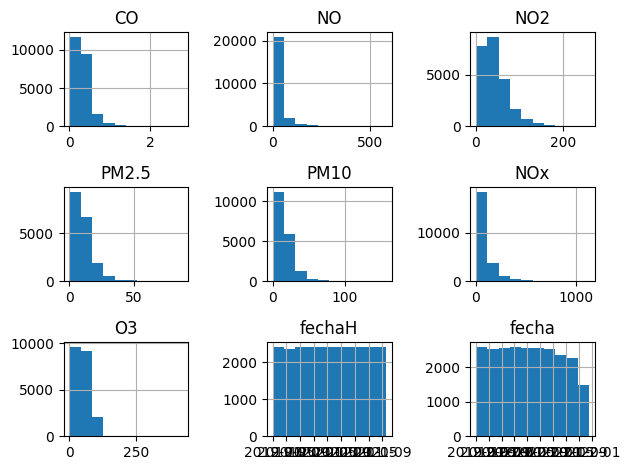

In [123]:
import matplotlib.pyplot as plt
df.hist()
plt.tight_layout()
plt.show()

### 5.2 Histogramas

Los histogramas ya nos dan una idea de la existencia de outliers

<Axes: >

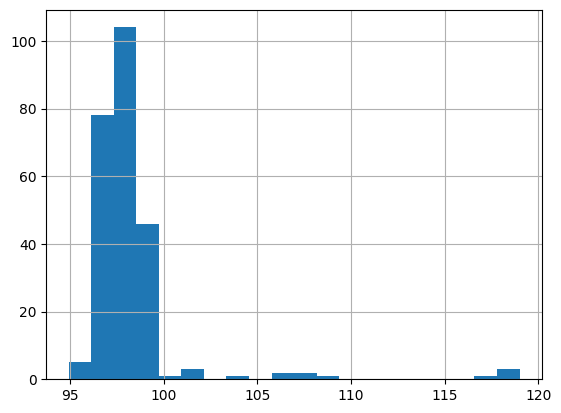

In [124]:
f1["LapTime"].hist(bins=20)

<Axes: >

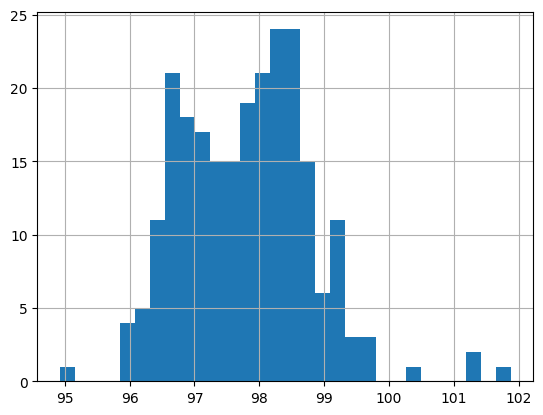

In [125]:
filtro = f1["LapTime"] < 103
f1[filtro]["LapTime"].hist(bins=30)

Parece que algunos bins aparecen muy a la derecha, son tiempos por vuelta inusualmente altos. 

Parece que un criterio sería encontrar bins con muy pocos valores, quizás tras varios "bins" vacíos. Para conocer el número de elementos en cada bin usaremos la función hist de plt, que nos devuelve estas frecuencias `n`, 

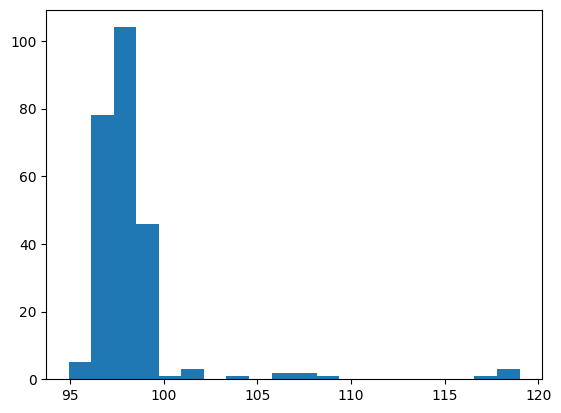

In [126]:
(n, bins, patches)  = plt.hist(f1["LapTime"],bins=20)

Vemos el número de elementos que caen en cada bin

In [127]:
n, len(n)

(array([  5.,  78., 104.,  46.,   1.,   3.,   0.,   1.,   0.,   2.,   2.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   3.]),
 20)

In [128]:
bins, len(bins)

(array([ 94.925 ,  96.1282,  97.3314,  98.5346,  99.7378, 100.941 ,
        102.1442, 103.3474, 104.5506, 105.7538, 106.957 , 108.1602,
        109.3634, 110.5666, 111.7698, 112.973 , 114.1762, 115.3794,
        116.5826, 117.7858, 118.989 ]),
 21)

In [129]:
((f1["LapTime"]>=94.925) & (f1["LapTime"]< 96.1282)).sum()

np.int64(5)

Parece que hay 3 bins muy llenos y muchos más vacíos o casi vacíos, parecería razonable en un primer vistazo decir que valores del intervalo [96.1282, 99.7378] 

<Axes: >

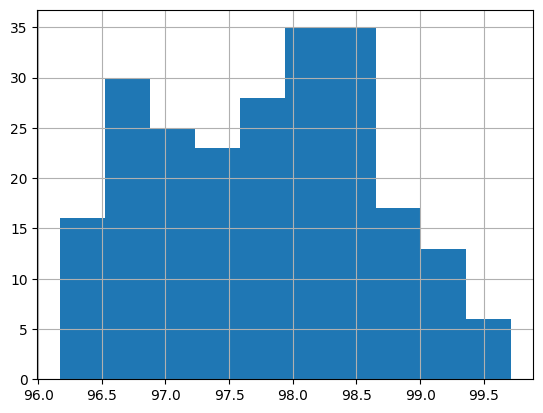

In [130]:
filtro = (f1["LapTime"]>=96.1282) & (f1["LapTime"]<=99.7378)
f1[filtro]["LapTime"].hist()

Sin outliers y por piloto

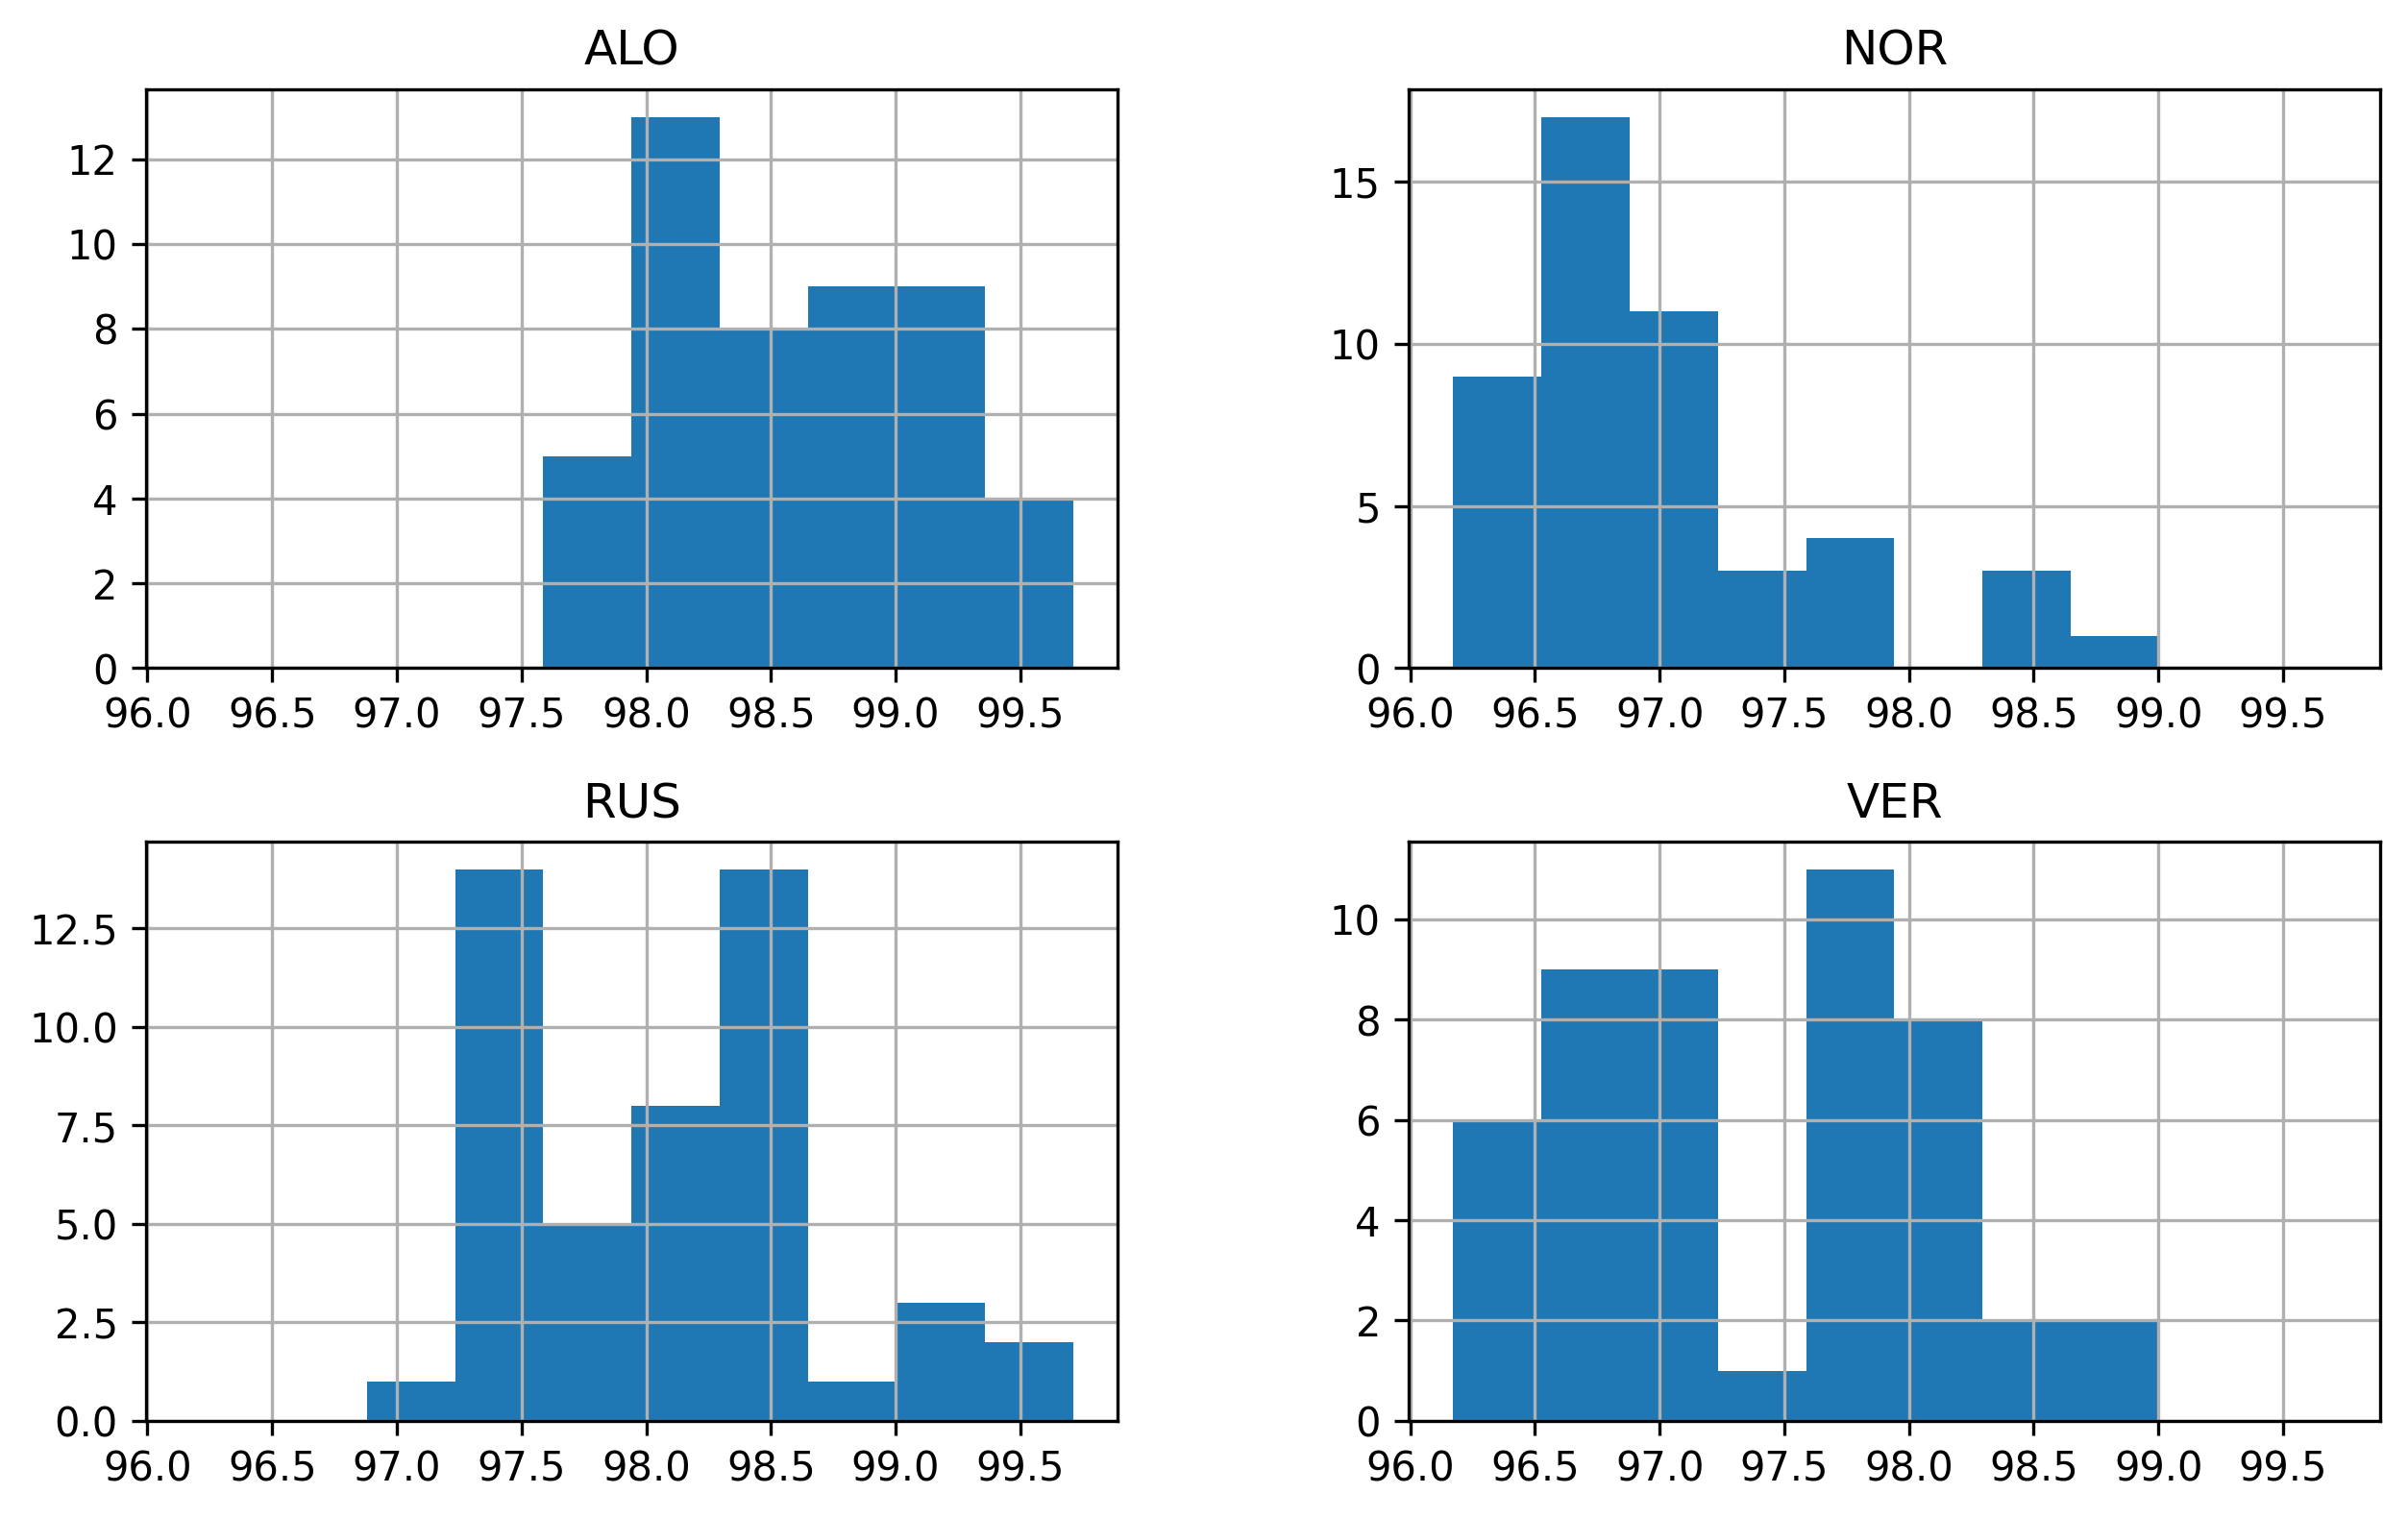

In [131]:
df_vueltas = f1.loc[filtro,["LapNumber","LapTime","Driver"]]
fig, ax = plt.subplots(2,2,figsize=(10, 6),dpi=300)

df_pilotos = df_vueltas.pivot(index="LapNumber", columns="Driver", values="LapTime").dropna()
df_pilotos.hist(ax=ax, range=[df_vueltas.LapTime.min() , df_vueltas.LapTime.max()])
plt.show()

In [132]:
df_pilotos

Driver,ALO,NOR,RUS,VER
LapNumber,,,,
2.0,99.584,98.480,98.489,98.790
3.0,99.286,98.406,99.712,98.917
4.0,99.395,98.446,99.170,98.470
5.0,99.036,97.938,98.604,97.906
6.0,98.795,97.843,98.372,97.997
7.0,98.720,97.621,98.365,97.774
8.0,98.542,97.082,98.260,97.669
9.0,98.644,96.715,98.174,97.890
10.0,98.765,96.830,98.332,97.739


<Axes: >

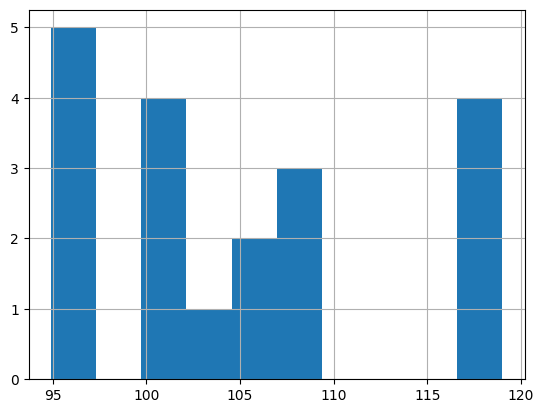

In [133]:
f1[~filtro]["LapTime"].hist()

In [134]:
f1[~filtro].style.background_gradient(cmap='Blues')

,Driver,LapTime,LapNumber,Sector1Time,Sector2Time,Sector3Time,SpeedST,Compound,TyreLife,Team,Position,InPit
0,NOR,100.424000,1.000000,nan,41.379000,27.852000,186.000000,MEDIUM,1.000000,McLaren,1.000000,False
28,NOR,101.878000,29.000000,28.963000,41.543000,31.372000,nan,MEDIUM,29.000000,McLaren,1.000000,False
29,NOR,107.073000,30.000000,29.259000,41.876000,35.938000,281.000000,MEDIUM,30.000000,McLaren,1.000000,True
30,NOR,118.408000,31.000000,49.556000,41.249000,27.603000,nan,HARD,1.000000,McLaren,1.000000,False
45,NOR,95.953000,46.000000,28.332000,40.577000,27.044000,284.000000,HARD,16.000000,McLaren,1.000000,False
47,NOR,94.925000,48.000000,28.238000,40.206000,26.481000,290.000000,HARD,18.000000,McLaren,1.000000,False
48,NOR,96.060000,49.000000,28.515000,40.596000,26.949000,287.000000,HARD,19.000000,McLaren,1.000000,False
62,VER,101.413000,1.000000,nan,41.689000,27.888000,189.000000,MEDIUM,1.000000,Red Bull Racing,2.000000,False
90,VER,107.873000,29.000000,29.284000,42.515000,36.074000,nan,MEDIUM,29.000000,Red Bull Racing,2.000000,True
91,VER,118.989000,30.000000,49.957000,41.662000,27.370000,nan,HARD,1.000000,Red Bull Racing,3.000000,False


### 5.3 BoxPlots

Sin embargo hay otro método que se utiliza más a menudo porque además da más información: los boxplots (también llamados en castellano "diagramas de cajas y bigotes"). Están basados en la mediana y los cuartiles (25% -> Q1, 75% -> Q3) muestran la siguiente información:

<img src="https://miro.medium.com/max/9000/1*2c21SkzJMf3frPXPAR_gZA.png" width=600/>

El criterio para declarar algo como outlier es por tanto ser  $< Q_1 - 1.5 \times (Q_3- Q_1)$  o  bien $> Q_3 + 1.5 \times (Q_3- Q_1)$

Se trata de un criterio bastante exigente porque en el caso de una normal suma más del 99% de la población

<img src="https://miro.medium.com/max/8100/1*NRlqiZGQdsIyAu0KzP7LaQ.png" width=600/>

En Python se pueden mostrar tanto con Pandas, como con Matplotlib, Plotly, como con Seaborn.

**Pandas**


<Axes: >

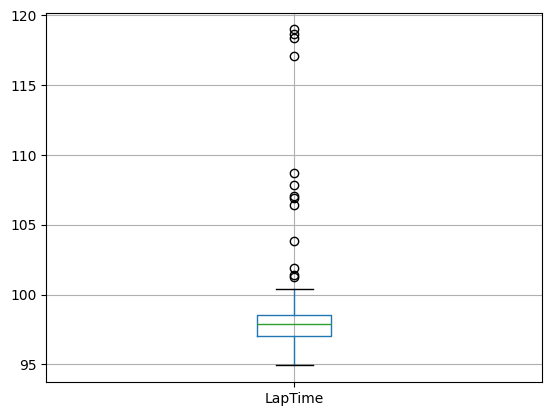

In [135]:
f1.boxplot(column = "LapTime")

<Axes: title={'center': 'LapTime'}, xlabel='Driver'>

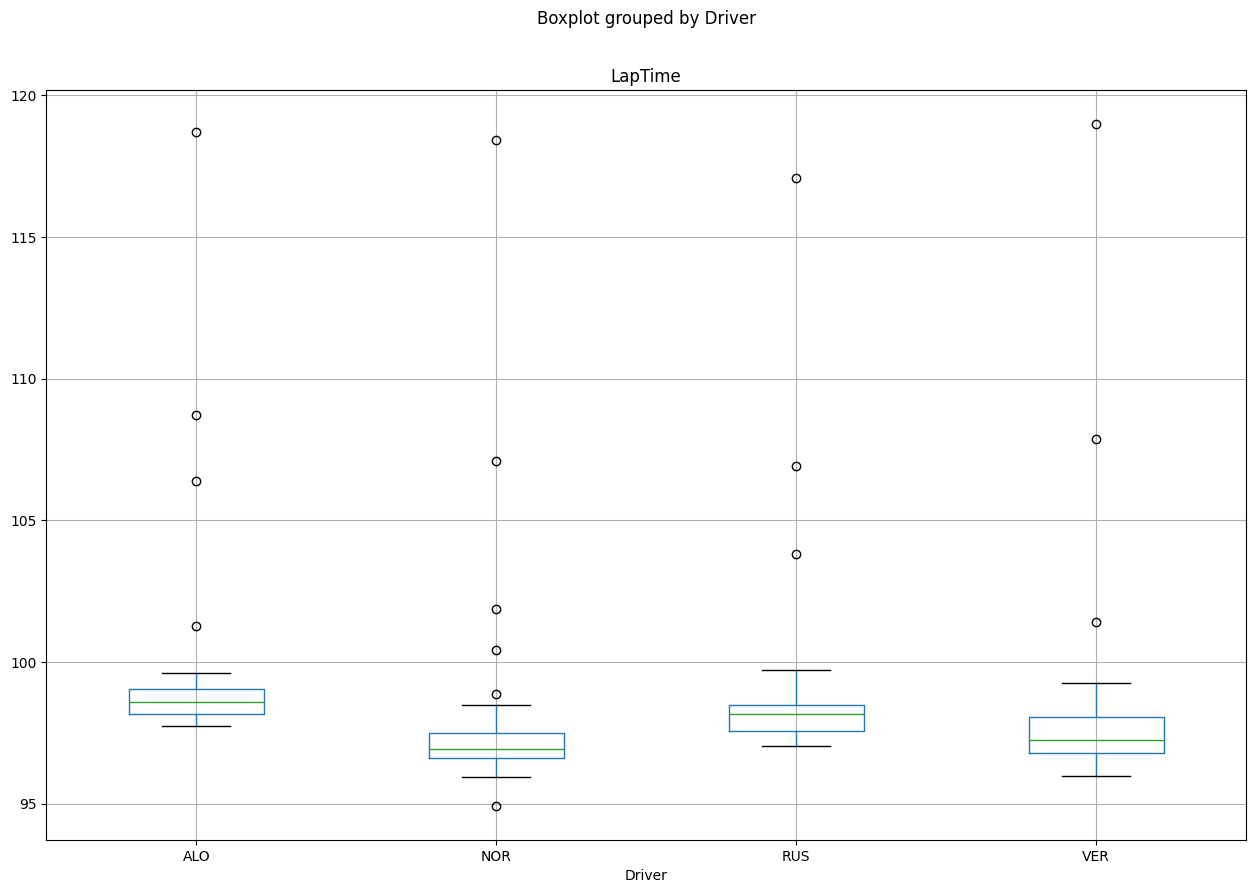

In [136]:
f1.boxplot(column = "LapTime", by="Driver",  figsize=(15,10))

**matplotlib**

Lo interesante que aporta es la posibilidad de incluir el notch que permite ver si la diferencia de mediana es estadísticamente significativa

C:\Users\usuario\AppData\Local\Temp\ipykernel_2132\3796676676.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df_pilotos.dropna(),    notch = True,labels=df_pilotos.columns)


{'whiskers': [<matplotlib.lines.Line2D at 0x1e351899a90>,
 'caps': [<matplotlib.lines.Line2D at 0x1e35189a000>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e3518998b0>,
 'medians': [<matplotlib.lines.Line2D at 0x1e35189a5d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x1e35189a6f0>,
 'means': []}

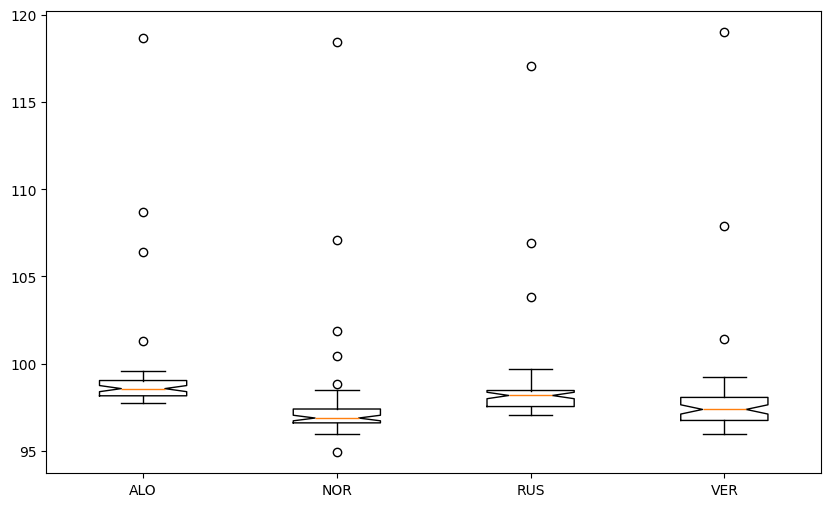

In [137]:
df_vueltas = f1[["LapNumber","LapTime","Driver"]]

df_pilotos = df_vueltas.pivot(index="LapNumber", columns="Driver", values="LapTime")

fig, ax = plt.subplots(figsize=(10, 6),dpi=100)
ax.boxplot(df_pilotos.dropna(),    notch = True,labels=df_pilotos.columns)

Un poco más bonito

C:\Users\usuario\AppData\Local\Temp\ipykernel_2132\1014902539.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplots = ax.boxplot(df_pilotos.dropna(), notch = True,labels=df_pilotos.columns,


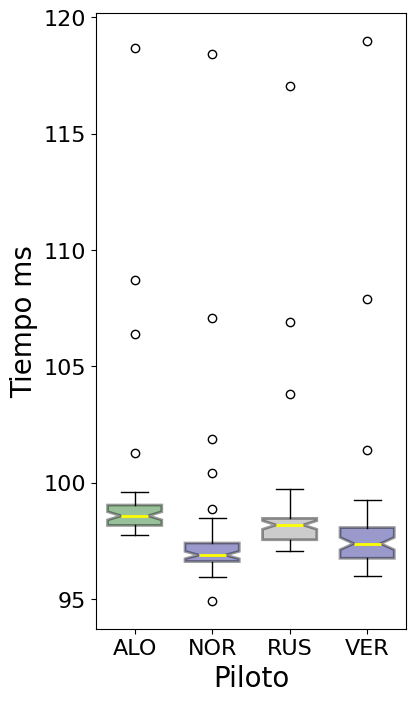

In [138]:
fig, ax = plt.subplots(figsize=(4, 8),dpi=100)
boxplots = ax.boxplot(df_pilotos.dropna(), notch = True,labels=df_pilotos.columns,
             widths = .7,
             patch_artist=True,
             medianprops = dict(linestyle='-', linewidth=2, color='Yellow'),
             boxprops = dict(linestyle='--', linewidth=2, color='Black', facecolor = 'blue', alpha = .4))
# colores
boxplots['boxes'][0].set_facecolor('darkgreen')
boxplots['boxes'][1].set_facecolor('navy')
boxplots['boxes'][2].set_facecolor('grey')
boxplots['boxes'][3].set_facecolor('navy')

plt.ylabel('Tiempo ms', fontsize = 20)
plt.xlabel('Piloto', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.show()

**Plotly**

In [139]:
import plotly.express as px
df = px.data.tips()
fig = px.box(f1, y="LapTime",width=1000, height=500)
fig.show()

In [140]:
import plotly.express as px

fig = px.box(f1, x="LapTime", y="Driver",  hover_data=['InPit','LapNumber'])
fig.show()

**Seaborn**

<Axes: xlabel='LapTime'>

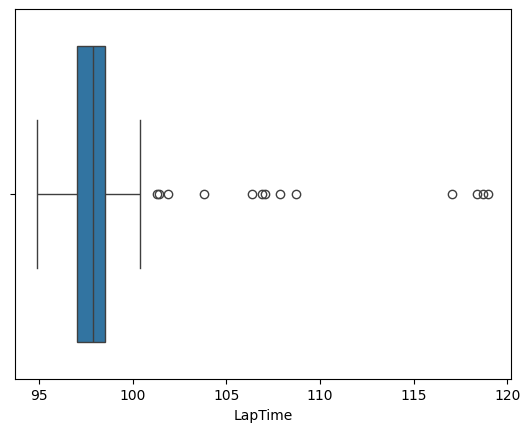

In [141]:
import seaborn as sns
sns.boxplot(x=f1["LapTime"])

C:\Users\usuario\AppData\Local\Temp\ipykernel_2132\824191171.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=f1["LapTime"],y=f1["Driver"],palette='Set3')


<Axes: xlabel='LapTime', ylabel='Driver'>

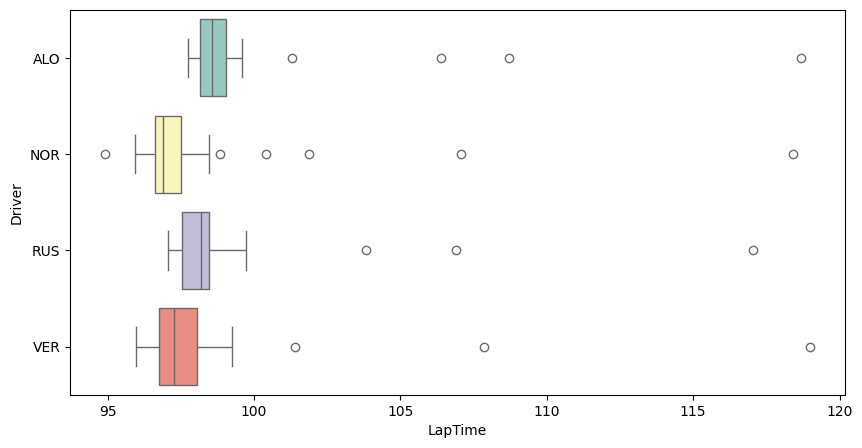

In [142]:
from matplotlib import pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 5),dpi=100)
sns.boxplot(x=f1["LapTime"],y=f1["Driver"],palette='Set3')

C:\Users\usuario\AppData\Local\Temp\ipykernel_2132\251409261.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=f1["LapTime"],y=f1["Compound"],palette='Set3')


<Axes: xlabel='LapTime', ylabel='Compound'>

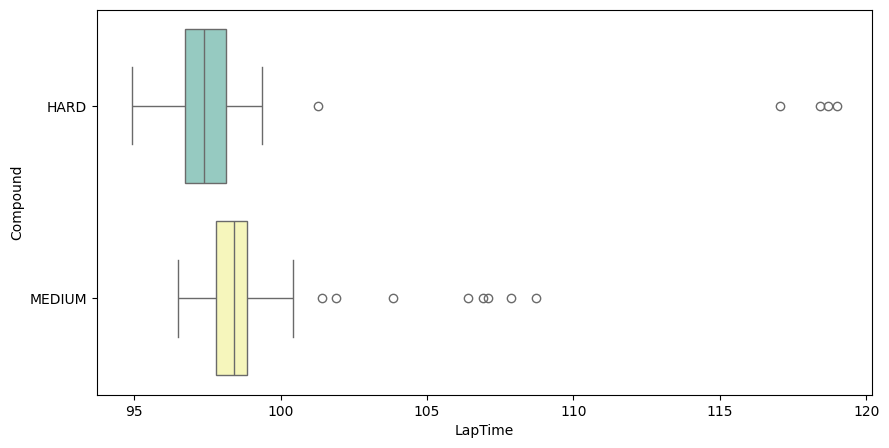

In [143]:
fig, ax = plt.subplots(figsize=(10, 5),dpi=100)
sns.boxplot(x=f1["LapTime"],y=f1["Compound"],palette='Set3')

In [144]:
columns = ['Sector1Time', 'Sector2Time', 'Sector3Time', 'Driver',"LapNumber"]
df_sectores = pd.melt(f1[~filtro][columns], id_vars=['Driver','LapNumber'])
df_sectores

,Driver,LapNumber,variable,value
0,NOR,1.0,Sector1Time,NaN
1,NOR,29.0,Sector1Time,28.963
2,NOR,30.0,Sector1Time,29.259
3,NOR,31.0,Sector1Time,49.556
4,NOR,46.0,Sector1Time,28.332
5,NOR,48.0,Sector1Time,28.238
6,NOR,49.0,Sector1Time,28.515
7,VER,1.0,Sector1Time,NaN
8,VER,29.0,Sector1Time,29.284
9,VER,30.0,Sector1Time,49.957


C:\Users\usuario\AppData\Local\Temp\ipykernel_2132\2234466940.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_sectores, x="value",y="Driver",palette='Set3')


<Axes: xlabel='value', ylabel='Driver'>

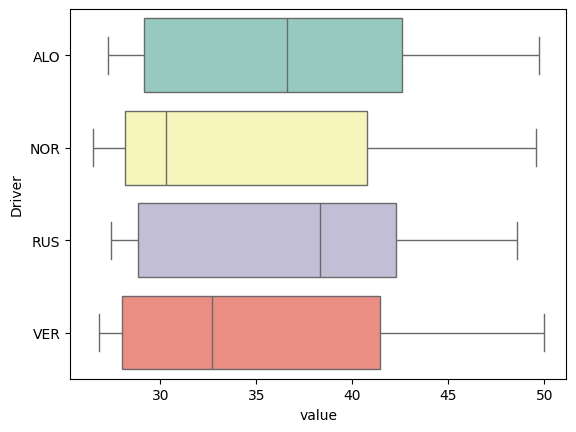

In [145]:
sns.boxplot(data = df_sectores, x="value",y="Driver",palette='Set3')

<Axes: xlabel='value', ylabel='variable'>

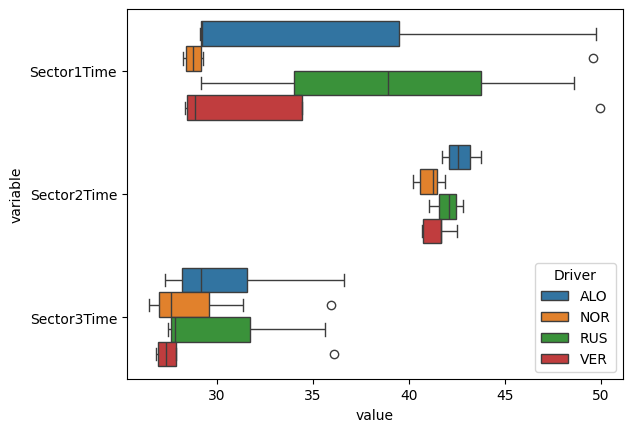

In [146]:
sns.boxplot(data = df_sectores, x="value",y="variable",hue="Driver")

### 5.4 Métodos numéricos

El primero ya lo hemos visto y es el que utilizan los boxplots; un valor x se considera outlier si 

$x< Q_1 - 1.5 \times (Q_3- Q_1)$  o  bien $x> Q_3 + 1.5 \times (Q_3- Q_1)$

Solo nos falta poder calcular $Q_1, Q_3$, pero el método `quantile`de Pandas lo pone muy fácil. Vamos a obtener los outliers para cada piloto:

In [147]:
df_vueltas = f1[["LapNumber","LapTime","Driver"]]

df_pilotos = df_vueltas.pivot(index="LapNumber", columns="Driver", values="LapTime")
df_pilotos

Driver,ALO,NOR,RUS,VER
LapNumber,,,,
1.0,106.384,100.424,103.822,101.413
2.0,99.584,98.480,98.489,98.790
3.0,99.286,98.406,99.712,98.917
4.0,99.395,98.446,99.170,98.470
5.0,99.036,97.938,98.604,97.906
...,...,...,...,...
58.0,98.265,97.734,97.796,96.171
59.0,98.101,96.948,98.326,95.967
60.0,98.573,96.631,97.872,96.343


In [148]:
import numpy as np
def muestra(driver,ax, x,inferior,superior,c):
    filtro_menor = x < inferior
    filtro_mayor = x > superior
    print(driver)
    print("Límites",round(inferior,3),round(superior,3))
    print("Rápido: ",np.round(x[filtro_menor].values,3))
    print("Lento: ",np.round(x[filtro_mayor].values,3)) 
    print("*"*100)
    return
    
    

#fig, ax = plt.subplots(figsize=(10, 6),dpi=100)
for i, driver in enumerate(df_pilotos.columns):
    x = df_pilotos[driver].dropna()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    inferior = q1 - 1.5*(q3-q1)
    superior = q3 + 1.5*(q3-q1)
    muestra(driver,ax,x,inferior,superior,driver)
    

        

ALO
Límites 96.848 100.348
Rápido:  []
Lento:  [106.384 108.707 118.688 101.282]
****************************************************************************************************
NOR
Límites 95.289 98.82
Rápido:  [94.925]
Lento:  [100.424 101.878 107.073 118.408  98.849]
****************************************************************************************************
RUS
Límites 96.168 99.839
Rápido:  []
Lento:  [103.822 106.903 117.061]
****************************************************************************************************
VER
Límites 94.835 99.988
Rápido:  []
Lento:  [101.413 107.873 118.989]
****************************************************************************************************


Otro método, el llamado *Hampel X84*  utiliza la mediana y el mad para indicar que los puntos que están separados más de $1.4826 \times \theta\times MAD$ de la mediana son puntos extremos, donde $\theta$ es un número positivo (1,2,3,...) que elegimos nosotros. Por ejemplo para $\theta=4$:

In [149]:
from scipy.stats import median_abs_deviation

driver = "ALO"
x = df_pilotos[driver].dropna()
mediana = x.median()
MAD = median_abs_deviation(x)

inferior = mediana -  1.4826*4*MAD
superior = mediana + 1.4826*4*MAD
filtro_outliers_sup = df_pilotos[driver] > superior
filtro_outliers_inf = df_pilotos[driver] < inferior

print("Outliers inferiores Alonso (vueltas sorprendentemente rápidas)", np.round(df_pilotos[driver][filtro_outliers_inf],3))
print("Outliers inferiores Alonso (vueltas sorprendentemente lentas)", np.round(df_pilotos[driver][filtro_outliers_sup],3))
print("Límites con  Hampel X84, theta=4, ",inferior,superior)

Outliers inferiores Alonso (vueltas sorprendentemente rápidas) Series([], Name: ALO, dtype: float64)
Outliers inferiores Alonso (vueltas sorprendentemente lentas) LapNumber
1.0     106.384
25.0    108.707
26.0    118.688
61.0    101.282
Name: ALO, dtype: float64
Límites con  Hampel X84, theta=4,  95.99327599999998 101.152724


### 5.5 Outliers en varias dimensiones


Consideramos el siguiente dataframe

In [150]:
### Create the Data
d1 = np.random.multivariate_normal(mean = np.array([-.5, 0]),
                               cov = np.array([[1, 0], [0, 1]]), size = 100)
d2 = np.random.multivariate_normal(mean = np.array([15, 10]),
                               cov = np.array([[1, 0.3], [.3, 1]]), size = 100)
outliers = np.array([[0, 10],[0, 9.5]])
df = pd.DataFrame(np.concatenate([d1, d2, outliers], axis = 0), columns = ['Var1', 'Var2'])
df

,Var1,Var2
0,-1.666709,0.262875
1,-0.722098,0.816777
2,-0.264702,2.182305
3,-0.416795,0.507353
4,-0.060234,0.865504
...,...,...
197,14.208435,9.602395
198,16.027803,11.119294
199,14.340056,10.825994
200,0.000000,10.000000


Aparentamente no hay outliers

<Axes: >

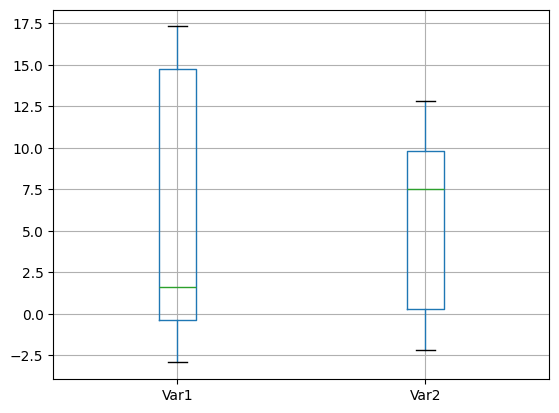

In [151]:
df.boxplot()

¿Seguro que no hay outliers? Veamos ambas columnas conjuntamente

<Axes: xlabel='Var1', ylabel='Var2'>

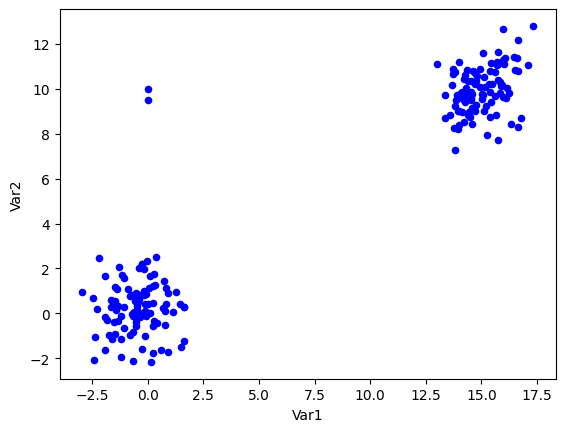

In [152]:
df.plot(kind='scatter', x='Var1', y='Var2', color='blue')

¿Cómo detectar estos puntos? La idea es que hay que tener una idea de punto "demasiado" alejado del resto, para eso utilizaremos 
la llamada [distancia de Mahalanobis](https://www.statisticshowto.com/mahalanobis-distance/) que tiene la distancia de un punto a un conjunto de puntos. Esto se hace mediante "envolturas elípticas" 

In [153]:
from sklearn.covariance import EllipticEnvelope
ee = EllipticEnvelope(contamination=.1).fit(df)  # la contaminación es la proporción de outliers, la decidimos nosotros
ee # una "envoltura"

,store_precision,True
,assume_centered,False
,support_fraction,None
,contamination,0.1
,random_state,None


In [154]:
p = ee.predict(df)
p # +1 normal, -1 outlier

array([ 1,  1,  1,  1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1,  1,
       -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1, -1])

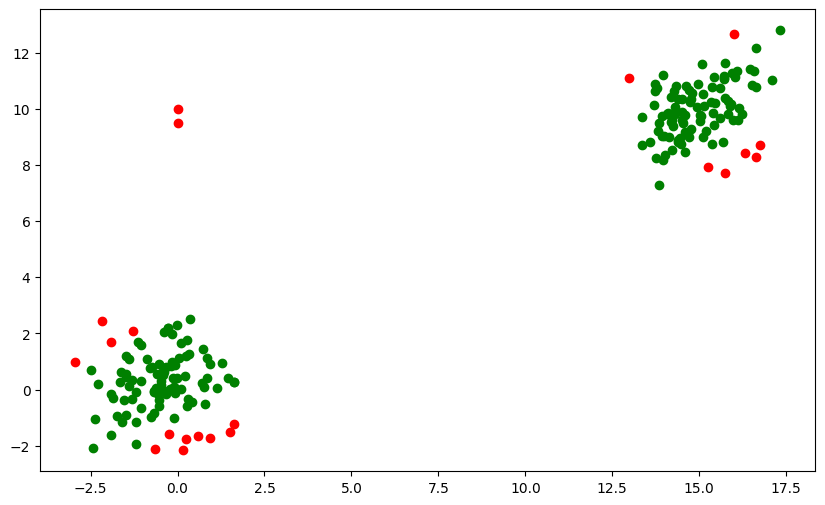

In [155]:
filtro = p==+1
normales = df[filtro]
outliers = df[~filtro]
fig, ax = plt.subplots(figsize=(10, 6),dpi=100)
ax.scatter(normales.Var1,normales.Var2,color="green")
ax.scatter(outliers.Var1,outliers.Var2,color="red")

en el ejemplo de la f1

In [156]:
df = df_pilotos.dropna()
ee = EllipticEnvelope(contamination=.01).fit(df)
p = ee.predict(df)
p

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [157]:
filtro = p==+1
normales = df[filtro]
outliers = df[~filtro]

outliers

Driver,ALO,NOR,RUS,VER
LapNumber,,,,
30.0,98.562,107.073,97.047,118.989


Un aviso: No funciona bien si las columnas no siguen ni aproximadamente una normal

## 6. Referencias
---
[Medidas de centralidad](https://statistics.laerd.com/statistical-guides/measures-central-tendency-mean-mode-median.php)<br>
[Biblioteca ydata-profiling](https://pypi.org/project/ydata-profiling/)<br>

[Notebook](https://github.com/mGalarnyk/Python_Tutorials/blob/master/Statistics/boxplot/Box_plot_interpretation.ipynb) con ejemplos de Boxplot incluyendo variantes como el "notch"

*Data Cleaning*. Ihab F. Ilyas and Xu Chu. Association for Computing Machinery 9781450371544 Tiene un capítulo dedicado a outliers muy completo


[Best Practices in Data Cleaning: A Complete Guide to Everything You Need to Do Before and After Collecting Your Data](http://pzs.dstu.dp.ua/DataMining/preprocessing/bibl/cleaning.pdf). Capítulo 7.
de Jason W. Osborne. Un poco técnico/estadístico pero muy preciso, 

[Outliers multivariante](https://medium.com/analytics-vidhya/anomaly-detection-in-python-part-1-basics-code-and-standard-algorithms-37d022cdbcff) Artículo de donde he tomado el código y el ejemplo para este apartado

[Outliers scikit-learn](https://scikit-learn.org/1.5/modules/outlier_detection.html) Ouliers con la biblioteca estándar de machine-learning. Quizás un poco complejo, pero muy potente.

[Cómo calcular el número óptimo de bins en un histograma](https://medium.com/@maxmarkovvision/optimal-number-of-bins-for-histograms-3d7c48086fde) (aportación de Odreman Ferrer)